# Импорт нужных библиотек

In [3]:
# Стандартные библиотеки Python для математических операций и работы с файловой системой
import math
import os
import random

# Отслеживание повторений в циклах
import tqdm

# Библиотека для выполнения HTTP-запросов к внешним API
import requests

# Специализированная библиотека для парсинга GPX-файлов (GPS Exchange Format)
import gpxpy

# Фундаментальные инструменты для работы с табличными данными и численными массивами
import pandas as pd
import numpy as np

# Геопространственные библиотеки для геокодирования и расчета расстояний
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
from meteostat import Point, Daily
import openmeteo_requests

# Библиотека для работы с данными OpenStreetMap и анализа окружающей среды
import osmnx as ox

# Инструменты для веб-автоматизации и создания интерактивных карт
import selenium
import folium
import io

# Обработка и аугментация изображений
from PIL import Image, ImageEnhance

# Библиотеки для визуализации данных и статистической графики
import seaborn as sb
import matplotlib.pyplot as plt

# Статистический анализ и проверка гипотез
from scipy import stats

# Алгоритмы машинного обучения: деревья решений, кластеризация, снижение размерности
from sklearn import tree
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder

# Библиотеки для работы с файлами
from pathlib import Path

# Библиотека для работы с базой данных
import sqlite3

from multiprocessing import Process

from datetime import datetime


# Создание Агента

In [61]:
class GPXAgent:

    """
    Класс для автоматизированной обработки и анализа GPS-треков.
    
    Attributes:
    gpx_data_path(str): Путь к папке с .gpx файлами
    max_track(str): Количество маршрутов, которые беруться с указанной папки
    """

    def __init__(self, gpx_data_path, max_track):
        """
        Инициализация экземпляра агента и загрузка данных.
        
        Parameters:
            gpx_data_path(str): Путь к папке с .gpx файлами
            max_track(str): Количество маршрутов, которые беруться с указанной папки
        """
        
        # Инициализация основной структуры данных с явно определенной схемой
        self.point_table = pd.DataFrame(columns = [
        "track_id", # Уникальный идентификатор GPS-трека
        "point_id", # Глобальный порядковый номер точки
        "time", # Временная метка точки
        "latitude", # Географическая широта (градусы)
        "longitude", # Географическая долгота (градусы)
        "elevation" # Высота над уровнем моря (метры)
        ])

        # Инициализация таблицы с "сырыми" .gpx файлами
        self.gpx_file_table = pd.DataFrame()
        
        # Инициализация вспомогательных атрибутов
        self.map_paths = None # Будет заполнено при создании карт
        self.inf_table = None # Резерв для дополнительной информации
        
        # Загрузка исходных данных с обработкой исключений в таблицу gpx_file_table
        data_dir = Path(gpx_data_path)
        csv_files = list(data_dir.iterdir())
        gpx_files = []
        for i in csv_files[1:]:
            with open(str(i), "r", encoding="utf-8") as f:
                gpx_files.append(gpxpy.parse(f))
        self.gpx_file_table = pd.concat([self.gpx_file_table, pd.Series(gpx_files, name="gpx")], axis=1)

        # Инициализация счетчиков для уникальных идентификаторов
        track_id = 1 # Счетчик треков
        point_id = 1 # Глобальный счетчик точек (сквозная нумерация)
        
        # Итерация по всем GPX-трекам в gpx_file_table
        for i in self.gpx_file_table["gpx"]:
            # Парсинг XML-строки GPX в объектную модель
            gpx = i
            for track in gpx.tracks:
                for segment in track.segments:
                    for point in segment.points:
                        # Создание строки DataFrame для текущей точки
                        line = pd.DataFrame({
                        "track_id": [track_id], # ID текущего трека
                        "point_id": [point_id], # Глобальный ID точки
                        "time": [point.time], # Временная метка
                        "latitude": [point.latitude], # Широта
                        "longitude": [point.longitude], # Долгота
                        "elevation": [point.elevation] # Высота
                        })
                        
                        # Добавление новой строки к основному датасету
                        self.point_table = pd.concat(
                        [self.point_table, line],
                        axis=0,
                        ignore_index=True
                        )
                        
                        point_id += 1
                        
                track_id += 1
        
                # Ограничение обработки заданным количеством треков
                if track_id == max_track + 1:
                    break

    def __convertColumnToNumeric(self) -> pd.DataFrame:
        """
        Приводит данные в датасете к пригодным для обработки моделями.
        """

        point_data = self.point_table
        if "place_type" in self.point_table.columns:
            point_data["place_type"] = point_data["place_type"].replace({"water": 0, "forest": 1, "buildings": 2})
        if "country" in self.point_table.columns:
            point_data = point_data.drop("country", axis=1)
        point_data["time"] = pd.to_datetime(point_data["time"]).astype("int64")
        return point_data
    
    def pars_temperature(self) -> pd.DataFrame:
        """
        Записывает температуру к каждой точке в датасете
        """

        total_column = []
        for i in tqdm.tqdm(self.point_table.index.tolist()):
            row = self.point_table.loc[i]
            location = Point(row['latitude'], row['longitude'])
            
            params = {
                "latitude": row['latitude'],
                "longitude": row['longitude'],
                "hourly": ["temperature_2m", "precipitation", "wind_speed_10m"],
            	"current": ["temperature_2m", "relative_humidity_2m"],
            }
            try:
                openmeteo = openmeteo_requests.Client()
                responses = openmeteo.weather_api("https://api.open-meteo.com/v1/forecast", params=params)
                response = responses[0]
                current = response.Current()
                temperature = current.Variables(0).Value()
            except Exception as e:
                print(f"Ошибка получения данных о температуры: {e}")
                continue
            total_column.append(temperature)
        
        self.point_table['temperature'] = total_column
        return self.point_table

    def pars_region(self) -> pd.DataFrame:
        """
        Записывает регион, в котором находится точка, в датасет.
        """
        
        country_column = []
        geolocator = Nominatim(user_agent="user_agenttt228", timeout=10)
        indices = self.point_table.index.tolist()
        for i in tqdm.tqdm(range(len(indices))):
            try:
                row = self.point_table.loc[i]
                location = geolocator.reverse(f"{row["latitude"]}, {row["longitude"]}")
            
                country_column.append(location.raw['address']["country"])
            except KeyError as e:
                country_column.append(None)
        country_column = pd.Series(country_column)
        country_column.name = "country"
        self.point_table = pd.concat([self.point_table , country_column], axis=1)
        return self.point_table

    def __check_features(self, lat: float, lon: float, radius=500) -> dict[str, int]:
        """
        Возвращает количество объектов в 500 метров вокруг точки.

        Args:
            lat (float): Широта точки
            lon (float): Долгота точки
            radius (int): Радиус вокруг точки, в котором будут браться объекты
        """
                
        features = {"water": 0, "forest": 0, "buildings": 0}

        max_retries = 3
        retry_count = 0
        
        query = f"""
        [out:json][timeout:10];
        (
          node(around:{radius},{lat},{lon})["natural"="water"];
          way(around:{radius},{lat},{lon})["natural"="water"];
          node(around:{radius},{lat},{lon})["waterway"];
          way(around:{radius},{lat},{lon})["waterway"];
          node(around:{radius},{lat},{lon})["natural"="wood"];
          way(around:{radius},{lat},{lon})["natural"="wood"];
          node(around:{radius},{lat},{lon})["natural"="forest"];
          way(around:{radius},{lat},{lon})["natural"="forest"];
          node(around:{radius},{lat},{lon})["building"];
          way(around:{radius},{lat},{lon})["building"];
        );
        out center;
        """
        response = requests.get(
            "https://overpass-api.de/api/interpreter", 
            params={'data': query}, 
            timeout=20
        )

        if response.status_code == 200:
            data = response.json()
            
            # Парсим результаты и считаем по типам
            for element in data.get('elements', []):
                tags = element.get('tags', {})
                
                # Проверяем тип объекта по тегам
                if tags.get('natural') == 'water' or tags.get('waterway'):
                    features['water'] += 1
                
                elif tags.get('natural') in ('wood', 'forest'):
                    features['forest'] += 1
                
                elif tags.get('building'):
                    features['buildings'] += 1
        return features
        
        
    def pars_features(self) -> pd.DataFrame:
        """
        Записывает объекты в радиусе 500 метров вокруг каждой точки в датасете.
        """
        
        results = []
        n = 3
        indices = self.point_table.index.tolist()
        
        for i in tqdm.tqdm(range(0, len(indices), n)):
            row = self.point_table.loc[i]
            features = self.__check_features(row["latitude"], row["longitude"])
            max_feature = max(features.items(), key=lambda x: x[1])[0]
            
            for _ in range(n):
                results.append({
                    'water_feature': features['water'],
                    'forest_feature': features['forest'],
                    'buildings_feature': features['buildings'],
                    'place_type': max_feature
                })
        
        
        features_df = pd.DataFrame(results)
        self.point_table = pd.concat([self.point_table, features_df], axis=1)
        self.point_table = self.point_table.dropna()
        
        return self.point_table
        
    def pars_steps(self):
        """
        Записывает количество шагов от одной точки до другой в датасет.
        """
        
        # Инициализация списка для хранения значений
        total_column = []
        
        # Константа средней длины шага человека (метры)
        # Эмпирическое значение, используемое в фитнес-трекерах
        step_distance = 0.7
        
        # Получение списка индексов для безопасной итерации
        indices = self.point_table.index.tolist()
        
        # Итерация по всем парам последовательных точек
        for i in tqdm.tqdm(range(len(indices) - 1)):
            # Извлечение текущей и следующей точек
            row = self.point_table.loc[i]
            next_row = self.point_table.loc[i + 1]
            
            # Вычисление геодезического расстояния между точками
            distance = geodesic(
            (row["latitude"], row["longitude"]),
            (next_row["latitude"], next_row["longitude"])
            )
            
            # Преобразование расстояния в количество шагов
            # distance.meters возвращает расстояние в метрах
            # Деление на step_distance дает оценку шагов
            # round() округляет до целого числа
            total_column.append(round(distance.meters / step_distance))
        
        # Добавление нулевого значения для последней точки
        # У последней точки нет "следующей" точки для расчета расстояния
        total_column.append(0)
        
        # Преобразование списка в pandas Series
        total_column = pd.Series(total_column)
        
        # Именование столбца
        total_column.name = "steps"
        
        # Добавление столбца к датафрейму
        self.point_table = pd.concat([self.point_table, total_column], axis=1)
        
        # Возврат обновленной таблицы
        return self.point_table

    def create_maps(self, save_path):
        """
        Создает карты, визуализирующие каждый маршрут и записывает путь до них в таблицу map_paths.

        Args:
            save_path (str): Путь, по которому будут сохранены карты
        """
        
        # Инициализация Series для хранения путей к картам
        self.map_paths = pd.Series("paths", name="map_paths")
        
        # Список для накопления точек текущего трека
        points = []
        
        # Счетчик обработанных карт
        count = 0
        
        # Вычисление центроидов (средних координат) для каждого трека
        # Используется для центрирования карты
        avg_lat = self.point_table.groupby("track_id")["latitude"].mean()
        avg_lon = self.point_table.groupby("track_id")["longitude"].mean()
        
        # Объединение в единый датафрейм
        avg_coordinates = pd.concat([avg_lat, avg_lon], axis=1)
        avg_coordinates.columns = ["avg_latitude", "avg_longitude"]
        
        # Получение индексов обоих датафреймов
        indices_avg_coordinates = avg_coordinates.index.tolist()
        indices_gpx_table = self.point_table.index.tolist()
        
        # Итерация по всем трекам
        for i in range(len(indices_avg_coordinates)):
            # Извлечение центроида текущего трека
            row = avg_coordinates.loc[i+1]

            # Создание объекта интерактивной карты folium
            m = folium.Map(
            location=[row["avg_latitude"], row["avg_longitude"]],
            zoom_start=10
            )
            
            # Создаем группу с именем маршрута для легенды
            route_group = folium.FeatureGroup(name='Маршрут')
            
            # Сбор всех точек, принадлежащих текущему треку
            for k in range(len(indices_gpx_table)):
                row_gpx = self.point_table.loc[k]
                
                # Проверка принадлежности точки к текущему треку
                if row_gpx["track_id"] == i+1:
                    # Добавление координат в список точек маршрута
                    points.append((row_gpx["latitude"], row_gpx["longitude"]))
            
            # Добавление полилинии (ломаной линии) на карту
            folium.PolyLine(points, tooltip="Coast", weight=5).add_to(route_group)
            
            # Добавляем группу на карту
            route_group.add_to(m)
            
            # Добавляем контроль слоев для отображения легенды
            folium.LayerControl(collapsed=False).add_to(m)
            
            # Рендеринг HTML-карты в растровое изображение PNG
            img_data = m._to_png(5)
            
            # Открытие изображения из байтового потока в памяти
            img = Image.open(io.BytesIO(img_data))
            
            # Сохранение изображения на диск
            img.save(f'{save_path}\\map_{count}.png')
            
            # Сохранение пути к файлу в Series
            self.map_paths.loc[count] = [f'{save_path}\\map_{count}.png']
        
            # Инкремент счетчика карт
            count += 1
        
        # Возврат Series с путями к сохраненным картам
        return self.map_paths

    def augmentation_image(self):
        """
        Аугментация изображений карт для расширения обучающего датасета.
        """
        
        # Проверка наличия созданных карт
        if type(self.map_paths) == None:
            print("Невозможно сделать аугментацию изображений, так как они не было созданы. "
            "Чтобы их создать, вспользуйтесь функций create_map")
            return
        
        # Получение индексов Series с путями к картам
        indices = self.map_paths.index.tolist()
        
        # Итерация по всем изображениям карт
        for i in range(len(indices)):
            # Извлечение пути к текущему изображению
            row = self.map_paths[i]
            
            # Загрузка изображения с диска
            img = Image.open(row[0])
            
            # Создание объектов для трансформации изображения
            brightness_changer = ImageEnhance.Brightness(img) # Яркость
            contrast_changer = ImageEnhance.Contrast(img) # Контраст
            sharpness_changer = ImageEnhance.Sharpness(img) # Резкость
            
            # Аугментация 1: Уменьшение яркости
            # Коэффициент < 1.0 затемняет изображение
            modified_image = brightness_changer.enhance(random.uniform(0.5, 0.9))
            try:
                modified_image.save(f"{row[0][:-4]}_modified_{1}.png")
            except Exception as e:
                print(f"Ошибка в сохранении изображения: {e}")
            
            # Аугментация 2: Увеличение яркости
            # Коэффициент > 1.0 осветляет изображение
            modified_image = brightness_changer.enhance(random.uniform(1.01, 1.3))
            try:
                modified_image.save(f"{row[0][:-4]}_modified_{2}.png")
            except Exception as e:
                print(f"Ошибка в сохранении изображения: {e}")
            
            # Аугментация 3: Уменьшение контраста
            # Снижает различие между светлыми и темными областями
            modified_image = contrast_changer.enhance(random.uniform(0.5, 0.9))
            try:
                modified_image.save(f"{row[0][:-4]}_modified_{3}.png")
            except Exception as e:
                print(f"Ошибка в сохранении изображения: {e}")
            
            # Аугментация 4: Увеличение контраста
            # Усиливает различие между светлыми и темными областями
            modified_image = contrast_changer.enhance(random.uniform(1.1, 1.6))
            try:
                modified_image.save(f"{row[0][:-4]}_modified_{4}.png")
            except Exception as e:
                print(f"Ошибка в сохранении изображения: {e}")
            
            # Аугментация 5: Уменьшение резкости (размытие)
            # Создает эффект небольшого размытия
            modified_image = sharpness_changer.enhance(random.uniform(0.5, 0.9))
            try:
                modified_image.save(f"{row[0][:-4]}_modified_{5}.png")
            except Exception as e:
                print(f"Ошибка в сохранении изображения: {e}")
            
            # Аугментация 6: Увеличение резкости
            # Подчеркивает границы и детали
            modified_image = sharpness_changer.enhance(random.uniform(1.1, 1.6))
            try:
                modified_image.save(f"{row[0][:-4]}_modified_{6}.png")
            except Exception as e:
                print(f"Ошибка в сохранении изображения: {e}")

    def graphic_distribution(self):
        """
        Визуализация распределений всех признаков датасета.
        """
        
        print("Графики")
        
        # Удаление технических столбцов, не представляющих интереса для анализа
        clear_gpx = self.point_table.drop(["track_id", "point_id", "time", "country"], axis=1)
        
        # Получение списка всех столбцов
        indices = clear_gpx.columns
        
        # Итерация по всем признакам
        for i in range(len(indices)-1):
            # Извлечение текущего столбца
            column = clear_gpx.iloc[:, i]
            # Специальная обработка категориального признака place_type
            if column.name == "place_type":
                # Создание столбчатой диаграммы для категорий
                # x указывает на столбец для группировки
                sb.barplot(x="place_type", data=pd.DataFrame(column))
                plt.show()
                continue
        
            # Для числовых признаков: гистограмма с KDE
            # histplot строит гистограмму распределения
            sb.histplot(column, kde=True)
        
            # Отображение графика
            plt.show()
        # Проведение статистического анализа нормальности
        stat, p = stats.shapiro(clear_gpx.drop("place_type", axis=1))
        print(f"Тест Шапиро-Уилка: статистика={stat:.4f}, p-значение={p:.4e}")
        if p > 0.05:
            print("Данные выглядят нормально (не отвергаем нулевую гипотезу)")
        else:
            print("Данные не выглядят нормально (отвергаем нулевую гипотезу)")

    def clusterization(self, clasters: int, table_writing = False):
        """
        Кластеризация GPS-точек методом K-средних с визуализацией и запись их в таблицу, если table_writing = True.

        Args:
            clasters (int): количество кластеров, на которые нужно поделить признаки
            table_writing (bool): выбор записывать кластеры втаблицу или нет
        """
        
        # Преобразуем не числовые данные
        data = self.__convertColumnToNumeric()
        
        # Снижение размерности методом PCA
        pca = PCA(n_components=2)
        
        # Удаление нечисловых столбцов перед применением PCA
        data_2d = pca.fit_transform(data)
        
        # Кластеризация методом K-средних
        kmeans = KMeans(n_clusters=clasters)
        
        # Обучение модели на исходных данных (не на PCA-проекции)
        # Это обеспечивает кластеризацию в полном признаковом пространстве
        kmeans.fit(data)
        
        # Предсказание меток кластеров для всех точек
        labels_km = kmeans.fit_predict(data)
        
        # Визуализация результатов кластеризации
        plt.scatter(
        data_2d[:, 0], # Первая главная компонента (ось X)
        data_2d[:, 1], # Вторая главная компонента (ось Y)
        c=labels_km, # Цвет точек определяется номером кластера
        cmap='viridis' # Цветовая схема (от фиолетового к желтому)
        )
        
        # Подписи осей
        plt.xlabel('x')
        plt.ylabel('y')
        
        # Отображение графика
        plt.show()
        
        # Опциональное сохранение меток в таблицу
        if table_writing:
            # Проверка наличия столбца cluster
            if "cluster" not in data.columns:
                # Если столбца нет - добавляем новый
                labels = pd.Series(labels_km)
                labels.name = "cluster"
                self.point_table = pd.concat([self.point_table, labels], axis=1)
            else:
                # Если столбец уже существует - удаляем старый и добавляем новый
                # Это позволяет переобучать кластеризацию с другими параметрами
                self.point_table = self.point_table.drop("cluster", axis=1)
                labels = pd.Series(labels_km)
                labels.name = "cluster"
                self.point_table = pd.concat([self.point_table, labels], axis=1)
        
    def db_save(self):
        """
        Сохранение готовой "чистой" таблицы в базу данных.
        """
        
        con = sqlite3.connect('clear_data.db')
        try:
            # Благодаря if_exists='replace' мы исключаем любые повторы в базе данных
            self.point_table.to_sql(con=con, name="Clear_data", if_exists='replace')
            return "Успешно!"
        except Exception as e:
            return f"Ошибка в сохранении в базу данных: {e}"

    def inf_table_read(self, path: str):
        """
        Сохранение таблицы с описанием всех признаков.

        Args:
            path (str): путь, где находится таблица с описанием признаков
        """
        
        self.inf_table = pd.read_csv(path)
        return "Таблица сохранена!"

    def correlation(self):
        """
        Проводим корреляцию данных, визуализируем их.
        """ 
        
        data = self.__convertColumnToNumeric()
        
        # Получение таблицы кореляции между данными
        corr = data.corr()
        
        # Визуализация полученных данных
        plt.figure(figsize=(10, 8))
        sb.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
        plt.title('Корреляционная матрица с аннотациями')
        plt.tight_layout()
        plt.show()

# Использование Агента

## Создание объекта класса GPXAgent

#### Загружаем .gpx файлы, проверяем получившуюся таблицу. Проверяем налицие пустых значений.

In [62]:
a = GPXAgent(gpx_data_path=r"C:\Users\demoexam\Cross_sections_modules\Number_1\Gpx_Track", max_track=2)

In [6]:
a.point_table

,track_id,point_id,time,latitude,longitude,elevation
0,1,1,2012-09-12 21:13:13+00:00,51.505713,104.139225,501.46
1,1,2,2012-09-12 21:13:19+00:00,51.505694,104.139221,505.79
2,1,3,2012-09-12 21:13:20+00:00,51.505693,104.139224,505.79
3,1,4,2012-09-12 21:13:30+00:00,51.505724,104.139204,511.56
4,1,5,2012-09-12 21:13:37+00:00,51.505717,104.139202,514.92
...,...,...,...,...,...,...
2741,2,2742,2022-07-16 09:35:57+00:00,51.737582,103.428106,669.33
2742,2,2743,2022-07-16 09:36:02+00:00,51.737811,103.427860,668.52
2743,2,2744,2022-07-16 09:36:07+00:00,51.738017,103.427555,668.27
2744,2,2745,2022-07-16 09:36:24+00:00,51.738100,103.427456,668.27


In [7]:
a.point_table.isna().sum()

track_id     0
point_id     0
time         0
latitude     0
longitude    0
elevation    0
dtype: int64

## Подсчет шагов между точками треков

In [8]:
a.pars_steps()

100%|██████████| 2745/2745 [00:00<00:00, 4124.69it/s]


,track_id,point_id,time,latitude,longitude,elevation,steps
0,1,1,2012-09-12 21:13:13+00:00,51.505713,104.139225,501.46,3
1,1,2,2012-09-12 21:13:19+00:00,51.505694,104.139221,505.79,0
2,1,3,2012-09-12 21:13:20+00:00,51.505693,104.139224,505.79,5
3,1,4,2012-09-12 21:13:30+00:00,51.505724,104.139204,511.56,1
4,1,5,2012-09-12 21:13:37+00:00,51.505717,104.139202,514.92,1
...,...,...,...,...,...,...,...
2741,2,2742,2022-07-16 09:35:57+00:00,51.737582,103.428106,669.33,44
2742,2,2743,2022-07-16 09:36:02+00:00,51.737811,103.427860,668.52,44
2743,2,2744,2022-07-16 09:36:07+00:00,51.738017,103.427555,668.27,16
2744,2,2745,2022-07-16 09:36:24+00:00,51.738100,103.427456,668.27,31


## Парсинг температуры на точках по широте и долготе

### Обрезаю датасет до 1000, для теста

In [9]:
a.point_table = a.point_table.iloc[:1000]

In [10]:
a.point_table

,track_id,point_id,time,latitude,longitude,elevation,steps
0,1,1,2012-09-12 21:13:13+00:00,51.505713,104.139225,501.46,3
1,1,2,2012-09-12 21:13:19+00:00,51.505694,104.139221,505.79,0
2,1,3,2012-09-12 21:13:20+00:00,51.505693,104.139224,505.79,5
3,1,4,2012-09-12 21:13:30+00:00,51.505724,104.139204,511.56,1
4,1,5,2012-09-12 21:13:37+00:00,51.505717,104.139202,514.92,1
...,...,...,...,...,...,...,...
995,1,996,2012-09-13 04:38:26+00:00,51.436646,104.007937,1957.86,10
996,1,997,2012-09-13 04:38:32+00:00,51.436709,104.007957,1957.86,17
997,1,998,2012-09-13 04:38:45+00:00,51.436813,104.007959,1954.02,29
998,1,999,2012-09-13 04:39:18+00:00,51.436993,104.007940,1950.17,23


In [11]:
a.pars_temperature()

100%|██████████| 1000/1000 [07:39<00:00,  2.18it/s]
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,track_id,point_id,time,latitude,longitude,elevation,steps,temperature
0,1,1,2012-09-12 21:13:13+00:00,51.505713,104.139225,501.46,3,-21.887001
1,1,2,2012-09-12 21:13:19+00:00,51.505694,104.139221,505.79,0,-21.887001
2,1,3,2012-09-12 21:13:20+00:00,51.505693,104.139224,505.79,5,-21.887001
3,1,4,2012-09-12 21:13:30+00:00,51.505724,104.139204,511.56,1,-21.887001
4,1,5,2012-09-12 21:13:37+00:00,51.505717,104.139202,514.92,1,-21.887001
...,...,...,...,...,...,...,...,...
995,1,996,2012-09-13 04:38:26+00:00,51.436646,104.007937,1957.86,10,-27.913502
996,1,997,2012-09-13 04:38:32+00:00,51.436709,104.007957,1957.86,17,-27.900501
997,1,998,2012-09-13 04:38:45+00:00,51.436813,104.007959,1954.02,29,-27.900501
998,1,999,2012-09-13 04:39:18+00:00,51.436993,104.007940,1950.17,23,-27.900501


## Парсинг объектов в радиусе 500 метров во круг точек из внешних источников (OpenStreetMap API)

In [12]:
a.pars_features()

100%|██████████| 334/334 [17:15<00:00,  3.10s/it]


,track_id,point_id,time,latitude,longitude,elevation,steps,temperature,water_feature,forest_feature,buildings_feature,place_type
0,1,1,2012-09-12 21:13:13+00:00,51.505713,104.139225,501.46,3.0,-21.887001,1,3,94,buildings
1,1,2,2012-09-12 21:13:19+00:00,51.505694,104.139221,505.79,0.0,-21.887001,1,3,94,buildings
2,1,3,2012-09-12 21:13:20+00:00,51.505693,104.139224,505.79,5.0,-21.887001,1,3,94,buildings
3,1,4,2012-09-12 21:13:30+00:00,51.505724,104.139204,511.56,1.0,-21.887001,1,3,94,buildings
4,1,5,2012-09-12 21:13:37+00:00,51.505717,104.139202,514.92,1.0,-21.887001,1,3,94,buildings
...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,996,2012-09-13 04:38:26+00:00,51.436646,104.007937,1957.86,10.0,-27.913502,0,0,0,water
996,1,997,2012-09-13 04:38:32+00:00,51.436709,104.007957,1957.86,17.0,-27.900501,1,0,0,water
997,1,998,2012-09-13 04:38:45+00:00,51.436813,104.007959,1954.02,29.0,-27.900501,1,0,0,water
998,1,999,2012-09-13 04:39:18+00:00,51.436993,104.007940,1950.17,23.0,-27.900501,1,0,0,water


## Парсинг региона на котором находится каждая точка

In [14]:
a.pars_region()

100%|██████████| 1000/1000 [17:35<00:00,  1.06s/it]


,track_id,point_id,time,latitude,longitude,elevation,steps,temperature,water_feature,forest_feature,buildings_feature,place_type,country
0,1,1,2012-09-12 21:13:13+00:00,51.505713,104.139225,501.46,3.0,-21.887001,1,3,94,buildings,Россия
1,1,2,2012-09-12 21:13:19+00:00,51.505694,104.139221,505.79,0.0,-21.887001,1,3,94,buildings,Россия
2,1,3,2012-09-12 21:13:20+00:00,51.505693,104.139224,505.79,5.0,-21.887001,1,3,94,buildings,Россия
3,1,4,2012-09-12 21:13:30+00:00,51.505724,104.139204,511.56,1.0,-21.887001,1,3,94,buildings,Россия
4,1,5,2012-09-12 21:13:37+00:00,51.505717,104.139202,514.92,1.0,-21.887001,1,3,94,buildings,Россия
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,996,2012-09-13 04:38:26+00:00,51.436646,104.007937,1957.86,10.0,-27.913502,0,0,0,water,Россия
996,1,997,2012-09-13 04:38:32+00:00,51.436709,104.007957,1957.86,17.0,-27.900501,1,0,0,water,Россия
997,1,998,2012-09-13 04:38:45+00:00,51.436813,104.007959,1954.02,29.0,-27.900501,1,0,0,water,Россия
998,1,999,2012-09-13 04:39:18+00:00,51.436993,104.007940,1950.17,23.0,-27.900501,1,0,0,water,Россия


## Кластеризация признаков

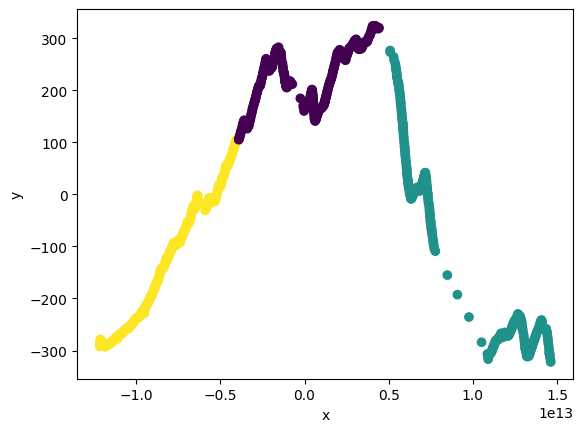

In [26]:
a.clusterization(3, table_writing=True)

### Было принято решение остановиться на трех кластерах, так как они не пересекаются и видны четкие границы

## Создание карты для каждого маршрута

In [28]:
a.create_maps(r"C:\Users\demoexam\Cross_sections_modules\Number_1\Track_Map")

0    [C:\Users\demoexam\Cross_sections_modules\Numb...
Name: map_paths, dtype: object

## Аугментация созданных карт, для увеличения выборки

In [29]:
a.augmentation_image()

## Сохранение в базу данных

In [30]:
a.db_save()

'Успешно!'

## Сохранение информационной таблицы

In [44]:
a.inf_table_read(r"C:\Users\demoexam\Cross_sections_modules\Number_1\info_table.csv")

'Таблица сохранена!'

In [47]:
a.inf_table

,Название,Перевод,Описание,Единицы измерения
0,track_id,Номер маршрута,Порядковый номер точки,-
1,point_id,Номер точки,Порядковый номер машрута,-
2,time,Время,Время в которое была пройдена точка,-
3,latitude,Широта,Координата точки,-
4,longitude,Долгота,Координата точки,-
5,elevation,Высота,"Высота, на которой находится точка",Метры
6,steps,Шаги,Пройденной растояние в шагах от одной точки до...,-
7,cluster,Кластеры,Каждая точка разделена на кластеры по схожести,-
8,country,Страна,"Страна, в которой рассположена точка",-
9,place_type,Тип местности,"Тип местности, вокруг точки в радиусе 500 метров",-


## Визуальный и не визуальный анализ датасета

Графики


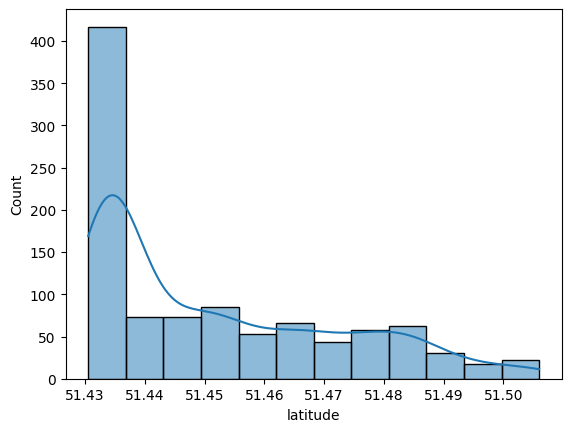

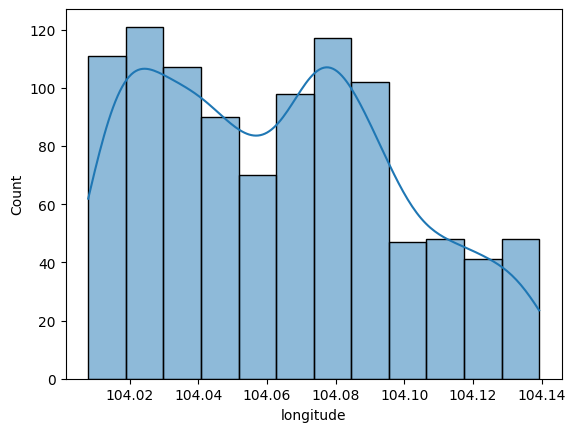

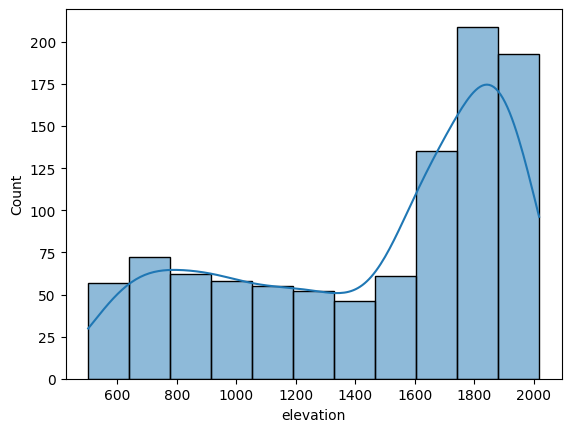

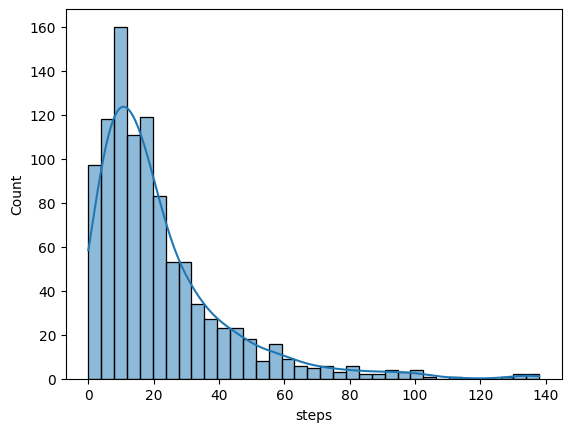

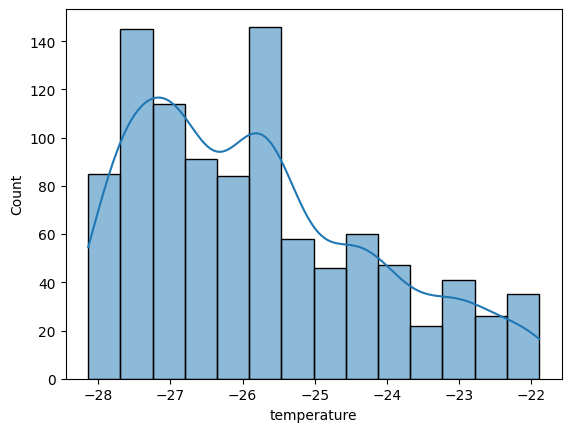

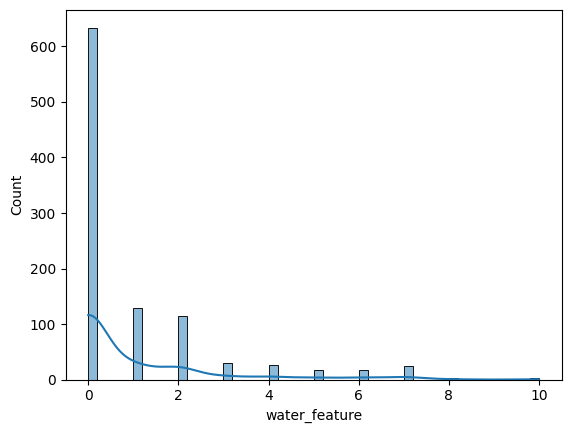

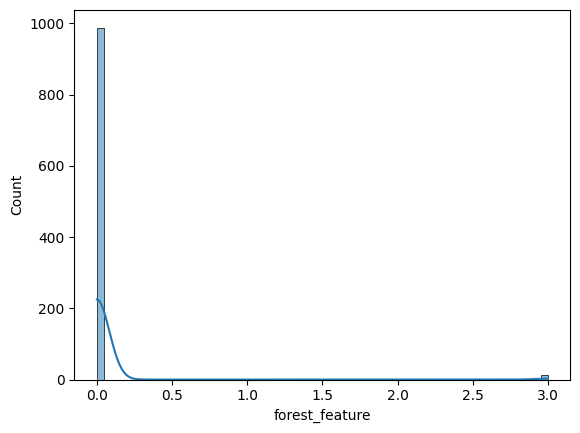

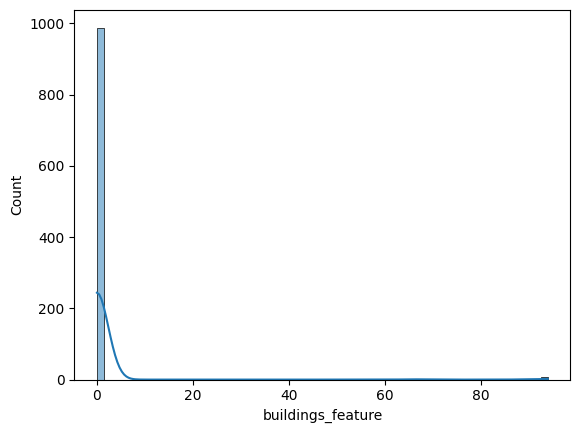

Тест Шапиро-Уилка: статистика=0.4591, p-значение=1.0830e-93
Данные не выглядят нормально (отвергаем нулевую гипотезу)


In [68]:
a.graphic_distribution()

### Проведя визуальный и статистический анализ данных, можно сделать вывод, что данные не выглядят нормальными. В случае с широтой скошенность положительная. В случае с высотой и долготой двупиковый тип данных. По анализу кластеризации, можно сделать вывод, что 3 кластер преобладает над другими, по этому вероятно в будущем потребуется нормализировать данные, для лучшего результата при обучении моделей.

## Кореляционный анализ данных

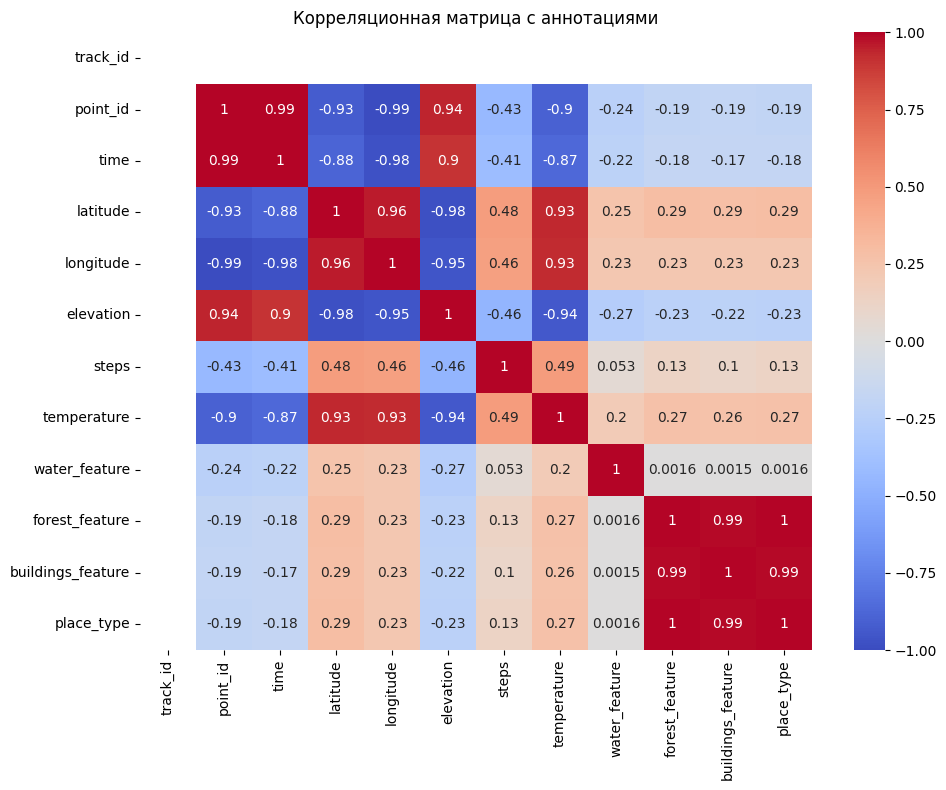

In [69]:
a.correlation()

### По результатам корреляции было выявленно, что все атрибуты влияют друг на друга и являются важными. Отдельно хочется отметить такие атрибуты как: "water_feature", "forest_feature", "buildings_feature", "place_type". Они меньше влияют на другие атрибуты, но хорошо влияют друг на друга и важны для будущих моделей, по этому удалены не будут.